In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import sklearn as sk
import scipy.stats as stats

#### Loading The datasets

In [3]:
customersDF = pd.read_csv('../data/raw/ecommerce_customers.csv')
order_itemsDF = pd.read_csv('../data/raw/ecommerce_order_items.csv')
ordersDF = pd.read_csv('../data/raw/ecommerce_orders.csv')
productsDF = pd.read_csv('../data/raw/ecommerce_products.csv')
reviewsDF = pd.read_csv('../data/raw/ecommerce_reviews.csv')
website_logsDF = pd.read_csv('../data/raw/ecommerce_website_logs.csv')

# Dataset 01 (CustomersDF)

### 1.1 Data Profiling

In [4]:
customersDF.head()

,customer_id,first_name,last_name,email,phone,age,city,registration_date,customer_segment,credit_score,total_spent,last_purchase_date
0,CUST_00000,Danielle,Johnson,john21@example.net,001-581-896-0013x3890,40,Annaba,2024-03-18,Standard,636.0,6786.35,NaN
1,CUST_00001,Joshua,Booth,helenpeterson@example.org,651.216.1559,29,Sidi Bel Abbès,2024-06-21,Standard,704.0,11496.74,NaN
2,CUST_00002,Teresa,Gray,maria95@example.net,610.934.1316,24,Batna,2023-05-09,Standard,508.0,5959.11,NaN
3,CUST_00003,Michael,Santiago,lynchgeorge@example.net,527.264.8350,27,BATNA,2024-01-25,Standard,620.0,16259.63,NaN
4,CUST_00004,Carl,Gentry,jason76@example.net,724.523.8849x696,37,Constantine,2024-05-23,Standard,454.0,3706.01,NaN


In [5]:
customersDF.describe()

,age,credit_score,total_spent,last_purchase_date
count,5250.000000,5224.000000,5250.000000,0.0
mean,34.084381,735.314319,9929.746402,NaN
std,12.147343,906.695499,7877.259382,NaN
min,-1.000000,300.000000,0.000000,NaN
25%,26.000000,583.000000,4363.377500,NaN
50%,34.000000,649.000000,8149.825000,NaN
75%,42.000000,718.000000,13489.027500,NaN
max,75.000000,9999.000000,61548.140000,NaN


In [6]:
customersDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5250 non-null   object 
 1   first_name          5250 non-null   object 
 2   last_name           5250 non-null   object 
 3   email               4829 non-null   object 
 4   phone               5238 non-null   object 
 5   age                 5250 non-null   int64  
 6   city                5250 non-null   object 
 7   registration_date   5250 non-null   object 
 8   customer_segment    5250 non-null   object 
 9   credit_score        5224 non-null   float64
 10  total_spent         5250 non-null   float64
 11  last_purchase_date  0 non-null      float64
dtypes: float64(3), int64(1), object(8)
memory usage: 492.3+ KB


In [7]:
def basic_profile_summary(df):
    print("=== BASIC PROFILE ===")
    print(f"Shape: {df.shape}")
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"Duplicate Rows: {df.duplicated().sum()}\n")

    print("=== DATA TYPES ===")
    print(df.dtypes, "\n")

    print("=== MISSING VALUES ===")
    print(df.isna().sum())


In [8]:
basic_profile_summary(customersDF)

=== BASIC PROFILE ===
Shape: (5250, 12)
Memory Usage: 2.87 MB
Duplicate Rows: 250

=== DATA TYPES ===
customer_id            object
first_name             object
last_name              object
email                  object
phone                  object
age                     int64
city                   object
registration_date      object
customer_segment       object
credit_score          float64
total_spent           float64
last_purchase_date    float64
dtype: object 

=== MISSING VALUES ===
customer_id              0
first_name               0
last_name                0
email                  421
phone                   12
age                      0
city                     0
registration_date        0
customer_segment         0
credit_score            26
total_spent              0
last_purchase_date    5250
dtype: int64


### 1.2 Missing Value Analysis

In [9]:
customersDF.isna().sum()

customer_id              0
first_name               0
last_name                0
email                  421
phone                   12
age                      0
city                     0
registration_date        0
customer_segment         0
credit_score            26
total_spent              0
last_purchase_date    5250
dtype: int64

In [10]:
(customersDF.isna().mean()*100)

customer_id             0.000000
first_name              0.000000
last_name               0.000000
email                   8.019048
phone                   0.228571
age                     0.000000
city                    0.000000
registration_date       0.000000
customer_segment        0.000000
credit_score            0.495238
total_spent             0.000000
last_purchase_date    100.000000
dtype: float64

In [11]:
def missing_value_report(df):
    missing_count = df.isna().sum()
    missing_percent = (df.isna().mean() * 100).round(2)

    report = pd.DataFrame({
        "Missing Count": missing_count,
        "Missing (%)": missing_percent
    })

    return report.sort_values("Missing (%)", ascending=False)


In [12]:
missing_report = missing_value_report(customersDF)
missing_report


,Missing Count,Missing (%)
last_purchase_date,5250,100.00
email,421,8.02
credit_score,26,0.50
phone,12,0.23
last_name,0,0.00
first_name,0,0.00
customer_id,0,0.00
age,0,0.00
registration_date,0,0.00
city,0,0.00


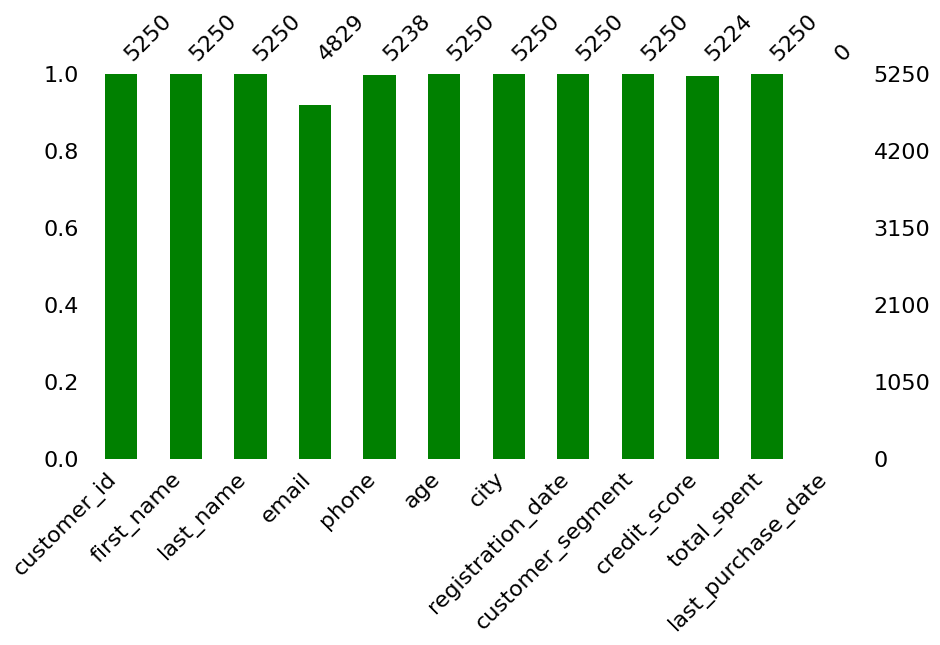

In [13]:
msno.bar(customersDF,color='green', figsize=(10,5))
plt.show()

### 1.3 Multiple Imputation

In [14]:
cleaned_customersDF = customersDF.copy()

In [15]:
cleaned_customersDF.drop(columns=['last_purchase_date'], inplace=True)
cleaned_customersDF.drop(columns=['customer_id'], inplace=True)

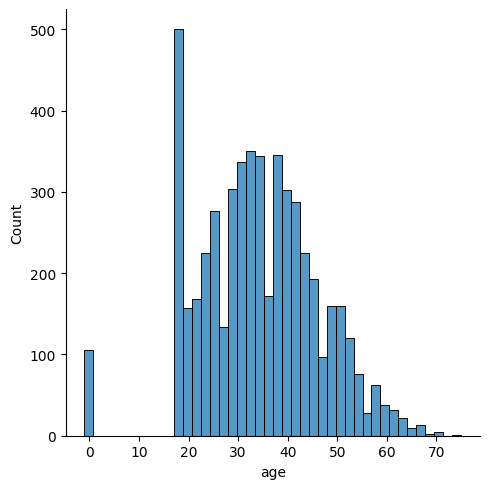

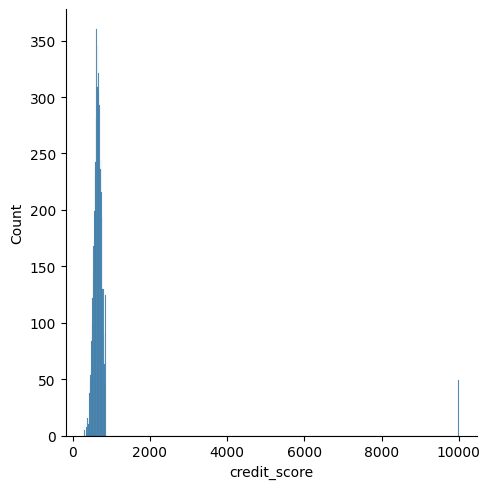

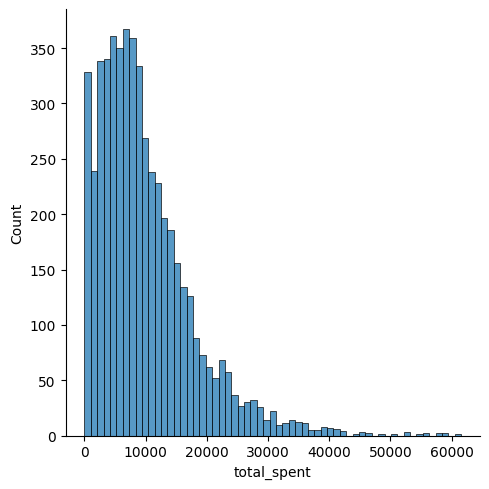

In [16]:
for col in cleaned_customersDF.select_dtypes(include=['int64','float64']).columns:
    sns.displot(cleaned_customersDF[col])    
    plt.show()  

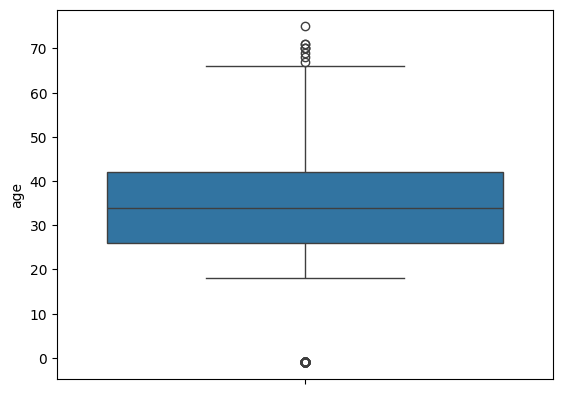

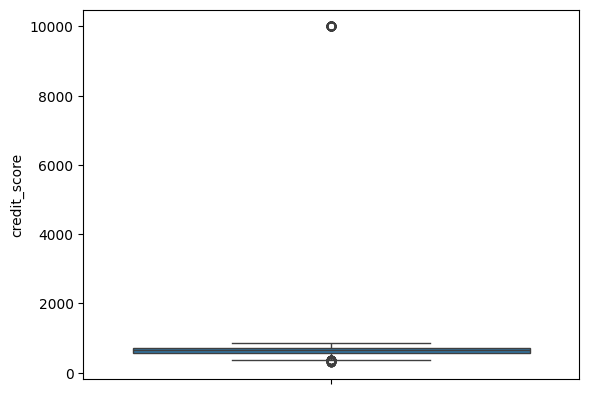

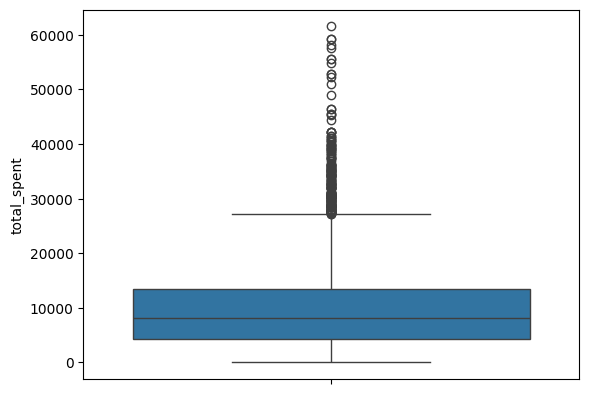

In [17]:
for col in cleaned_customersDF.select_dtypes(include=['int64','float64']).columns:
    sns.boxplot(data=cleaned_customersDF[col])
    plt.show()

In [18]:
cleaned_customersDF.loc[(cleaned_customersDF['age'] < 5), 'age']= np.nan

In [19]:
cleaned_customersDF.loc[(cleaned_customersDF['credit_score'] > 850), 'credit_score'] = np.nan

In [20]:
missing_report = missing_value_report(cleaned_customersDF)
missing_report

,Missing Count,Missing (%)
email,421,8.02
age,105,2.00
credit_score,75,1.43
phone,12,0.23
last_name,0,0.00
first_name,0,0.00
city,0,0.00
registration_date,0,0.00
customer_segment,0,0.00
total_spent,0,0.00


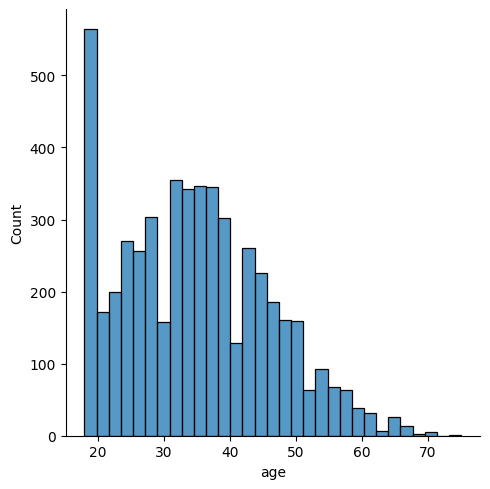

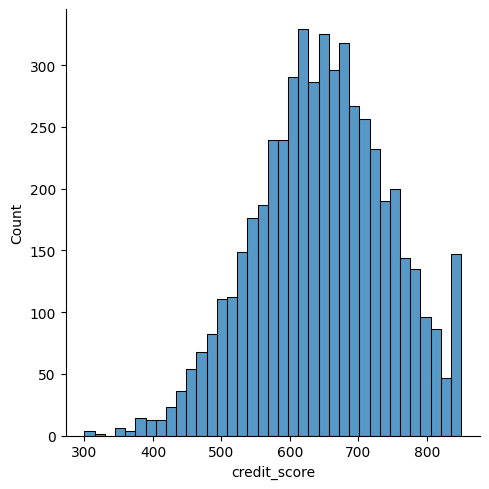

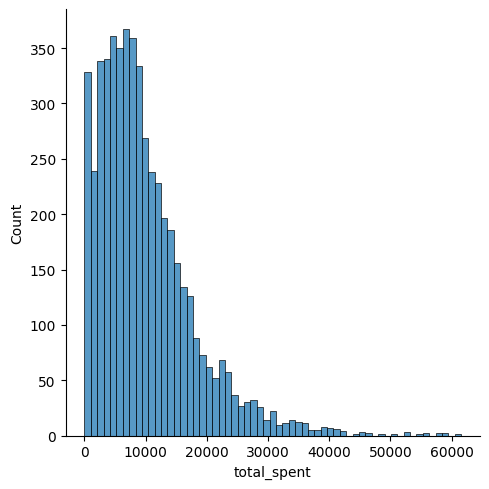

In [21]:
for col in cleaned_customersDF.select_dtypes(include=['int64','float64']).columns:
    sns.displot(cleaned_customersDF[col])    
    plt.show() 

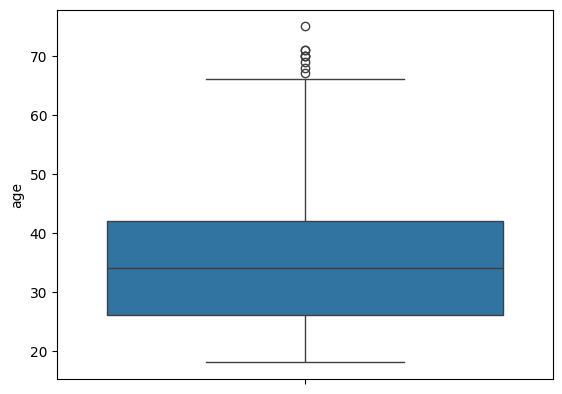

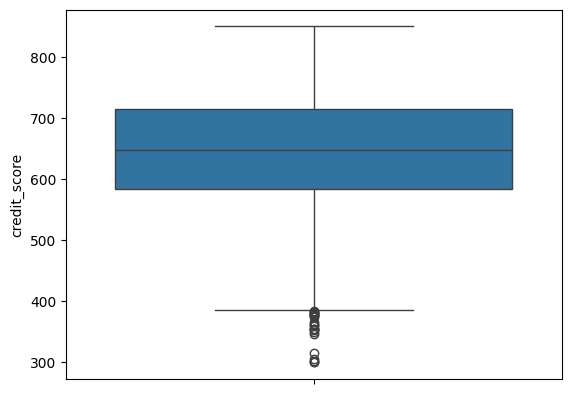

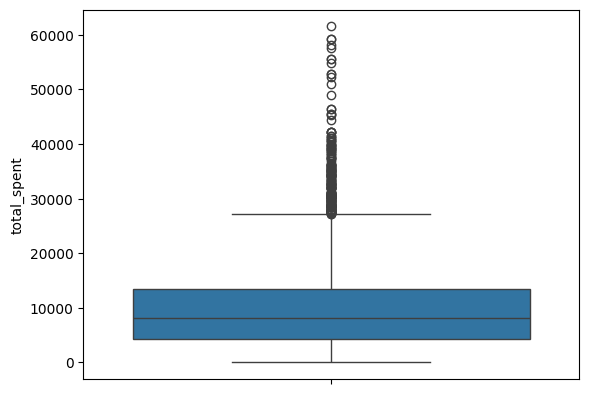

In [22]:
for col in cleaned_customersDF.select_dtypes(include=['int64','float64']).columns:
    sns.boxplot(data=cleaned_customersDF[col])
    plt.show()

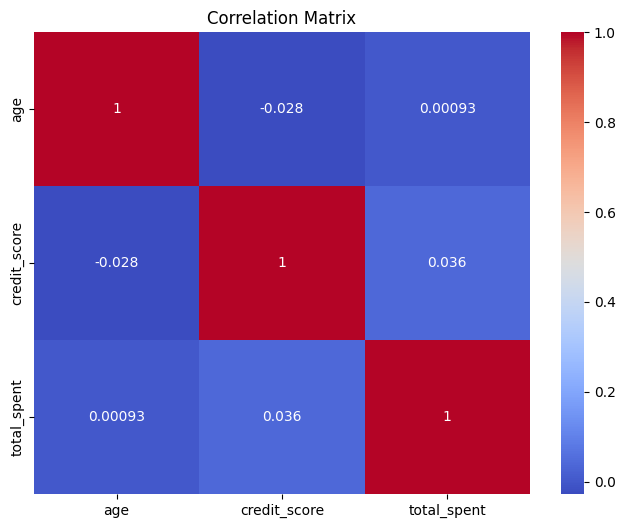

In [23]:
corr = cleaned_customersDF.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [24]:
cleaned_customersDF.groupby("city")["age"].mean()

city
ALGIERS           35.500000
ANNABA            32.233333
Algiers           35.445607
Annaba            34.479452
BATNA             30.400000
BISKRA            32.666667
BLIDA             32.200000
Batna             34.794926
Biskra            34.652941
Blida             34.345382
CONSTANTINE       35.863636
Constantine       35.358531
ORAN              35.409091
Oran              35.120240
SIDI BEL ABBÈS    36.000000
Sidi Bel Abbès    35.241107
SÉTIF             37.941176
Sétif             34.349901
TLEMCEN           31.000000
Tlemcen           34.725207
Name: age, dtype: float64

In [25]:
cleaned_customersDF.groupby("city")["age"].median()

city
ALGIERS           34.0
ANNABA            30.5
Algiers           35.0
Annaba            34.0
BATNA             26.5
BISKRA            30.5
BLIDA             30.0
Batna             34.0
Biskra            34.0
Blida             34.0
CONSTANTINE       35.5
Constantine       36.0
ORAN              36.5
Oran              34.0
SIDI BEL ABBÈS    36.5
Sidi Bel Abbès    34.0
SÉTIF             40.0
Sétif             33.0
TLEMCEN           30.0
Tlemcen           35.0
Name: age, dtype: float64

In [26]:
cleaned_customersDF.groupby("customer_segment")["age"].mean()

customer_segment
Basic       34.788845
Premium     34.677003
Standard    34.835687
Name: age, dtype: float64

In [27]:
cleaned_customersDF.groupby("customer_segment")["age"].median()

customer_segment
Basic       34.0
Premium     34.0
Standard    34.0
Name: age, dtype: float64

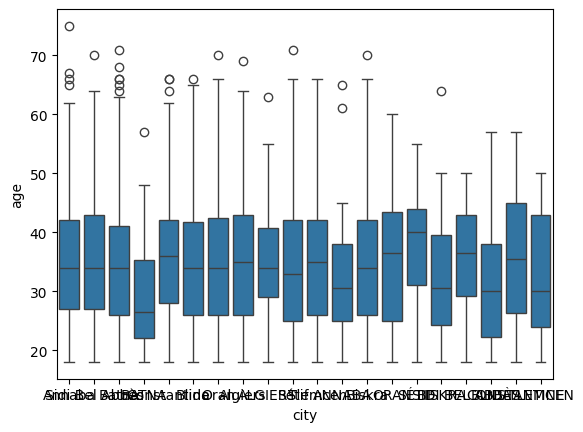

In [28]:
sns.boxplot(x="city", y="age", data=cleaned_customersDF)
plt.show()


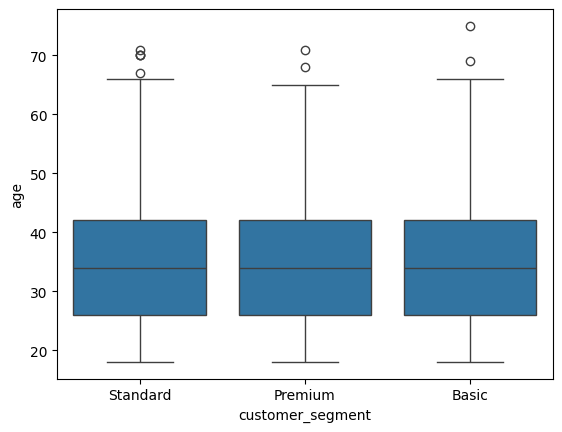

In [29]:
sns.boxplot(x="customer_segment", y="age", data=cleaned_customersDF)
plt.show()

In [30]:
groups = [g["age"].dropna() for _, g in cleaned_customersDF.groupby("city")]
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(0.9137524184264123), pvalue=np.float64(0.5654466067070945))

In [31]:
groups = [g["age"].dropna() for _, g in cleaned_customersDF.groupby("customer_segment")]
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(0.06334409894945858), pvalue=np.float64(0.9386211722321823))

In [32]:
missing = cleaned_customersDF["age"].isna()
cleaned_customersDF.loc[missing, "age"] = np.random.choice(cleaned_customersDF["age"].dropna(), size=missing.sum())

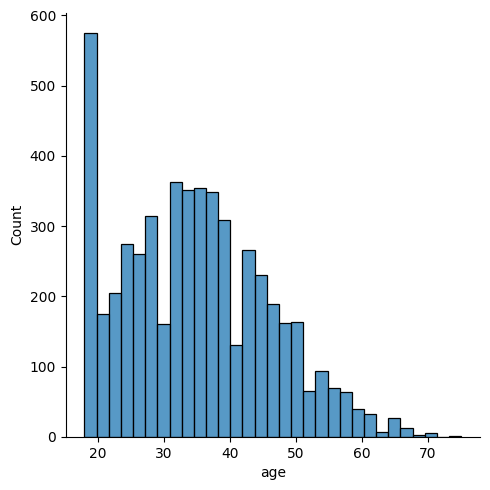

In [33]:
sns.displot(cleaned_customersDF['age'])    
plt.show() 

In [34]:
cleaned_customersDF.groupby("city")["credit_score"].mean()

city
ALGIERS           644.222222
ANNABA            664.666667
Algiers           652.659664
Annaba            645.211350
BATNA             688.913043
BISKRA            657.235294
BLIDA             645.350000
Batna             644.473684
Biskra            650.829502
Blida             648.694444
CONSTANTINE       625.863636
Constantine       645.692308
ORAN              651.909091
Oran              651.530938
SIDI BEL ABBÈS    661.900000
Sidi Bel Abbès    644.070588
SÉTIF             646.944444
Sétif             640.798000
TLEMCEN           679.360000
Tlemcen           647.621901
Name: credit_score, dtype: float64

In [35]:
cleaned_customersDF.groupby("city")["credit_score"].median()

city
ALGIERS           648.0
ANNABA            678.0
Algiers           656.0
Annaba            646.0
BATNA             708.0
BISKRA            661.0
BLIDA             621.0
Batna             647.0
Biskra            650.0
Blida             647.5
CONSTANTINE       616.0
Constantine       645.0
ORAN              663.5
Oran              654.0
SIDI BEL ABBÈS    656.5
Sidi Bel Abbès    645.0
SÉTIF             661.0
Sétif             633.0
TLEMCEN           690.0
Tlemcen           650.0
Name: credit_score, dtype: float64

In [36]:
cleaned_customersDF.groupby("customer_segment")["credit_score"].mean()

customer_segment
Basic       650.052423
Premium     650.587786
Standard    645.863578
Name: credit_score, dtype: float64

In [37]:
cleaned_customersDF.groupby("customer_segment")["credit_score"].median()

customer_segment
Basic       654.0
Premium     651.5
Standard    645.0
Name: credit_score, dtype: float64

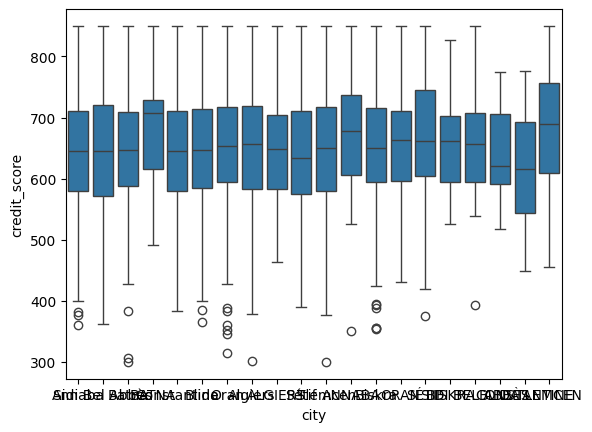

In [38]:
sns.boxplot(x="city", y="credit_score", data=cleaned_customersDF)
plt.show()

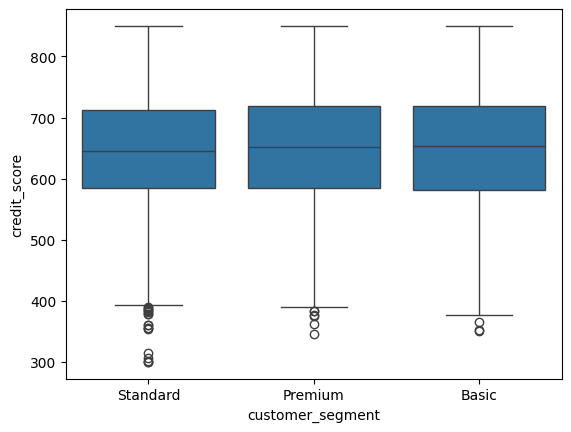

In [39]:
sns.boxplot(x="customer_segment", y="credit_score", data=cleaned_customersDF)
plt.show()

In [40]:
groups = [g["credit_score"].dropna() for _, g in cleaned_customersDF.groupby("city")]
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(0.8596579261021359), pvalue=np.float64(0.6348528493516865))

In [41]:
groups = [g["credit_score"].dropna() for _, g in cleaned_customersDF.groupby("customer_segment")]
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(1.2681383711329675), pvalue=np.float64(0.28144238210173694))

In [42]:
cleaned_customersDF["credit_score"] = cleaned_customersDF["credit_score"].fillna(cleaned_customersDF["credit_score"].median())


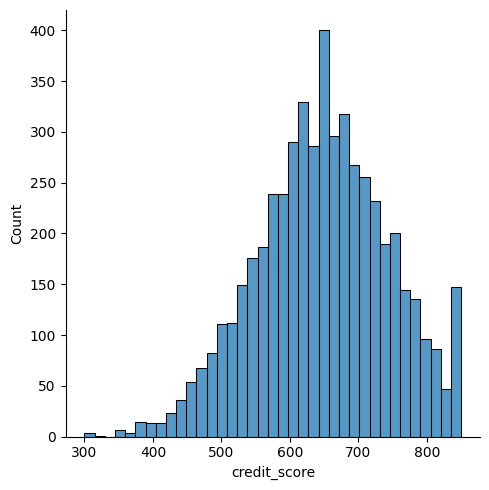

In [43]:
sns.displot(cleaned_customersDF['credit_score'])    
plt.show() 

In [44]:
missing_report = missing_value_report(cleaned_customersDF)
missing_report

,Missing Count,Missing (%)
email,421,8.02
phone,12,0.23
last_name,0,0.00
first_name,0,0.00
age,0,0.00
city,0,0.00
registration_date,0,0.00
customer_segment,0,0.00
credit_score,0,0.00
total_spent,0,0.00


In [45]:
cleaned_customersDF["email"] = cleaned_customersDF["email"].fillna("missing")
cleaned_customersDF["phone"] = cleaned_customersDF["phone"].fillna("missing")


In [46]:
cleaned_customersDF["customer_id"] = customersDF["customer_id"]

In [47]:
basic_profile_summary(cleaned_customersDF)

=== BASIC PROFILE ===
Shape: (5250, 11)
Memory Usage: 2.85 MB
Duplicate Rows: 247

=== DATA TYPES ===
first_name            object
last_name             object
email                 object
phone                 object
age                  float64
city                  object
registration_date     object
customer_segment      object
credit_score         float64
total_spent          float64
customer_id           object
dtype: object 

=== MISSING VALUES ===
first_name           0
last_name            0
email                0
phone                0
age                  0
city                 0
registration_date    0
customer_segment     0
credit_score         0
total_spent          0
customer_id          0
dtype: int64


In [48]:
cleaned_customersDF.duplicated().sum()

np.int64(247)

In [49]:
cleaned_customersDF['customer_id'].value_counts()[cleaned_customersDF['customer_id'].value_counts() > 1]


customer_id
CUST_01250    2
CUST_00354    2
CUST_00968    2
CUST_01829    2
CUST_02319    2
             ..
CUST_04898    2
CUST_04905    2
CUST_04915    2
CUST_04922    2
CUST_04924    2
Name: count, Length: 250, dtype: int64

In [50]:
cleaned_customersDF[cleaned_customersDF['customer_id'].duplicated(keep=False)].sort_values('customer_id')


,first_name,last_name,email,phone,age,city,registration_date,customer_segment,credit_score,total_spent,customer_id
28,Shawn,Rogers,aramirez@example.com,270-580-5310,18.0,ANNABA,2025-05-19,Basic,668.0,28573.20,CUST_00028
5176,Shawn,Rogers,aramirez@example.com,270-580-5310,18.0,ANNABA,2025-05-19,Basic,668.0,28573.20,CUST_00028
68,Latoya,Huang,kstout@example.net,759.378.2071,36.0,Biskra,2024-10-20,Standard,634.0,9394.96,CUST_00068
5081,Latoya,Huang,kstout@example.net,759.378.2071,36.0,Biskra,2024-10-20,Standard,634.0,9394.96,CUST_00068
69,Benjamin,Zimmerman,nwarren@example.org,(854)666-5905x151,38.0,Blida,2025-01-13,Standard,850.0,38790.28,CUST_00069
...,...,...,...,...,...,...,...,...,...,...,...
5174,Rebecca,Turner,missing,890.307.4628,18.0,Oran,2023-01-11,Standard,700.0,23910.04,CUST_04915
5079,Randall,Wood,manningsara@example.net,6043386526,46.0,Biskra,2025-02-05,Standard,648.0,10501.45,CUST_04922
4922,Randall,Wood,manningsara@example.net,6043386526,46.0,Biskra,2025-02-05,Standard,648.0,10501.45,CUST_04922
5035,randy,Allen,vaughnangela@example.org,643-873-1676x98751,18.0,Blida,2025-10-04,Standard,616.0,7954.13,CUST_04924


In [51]:
cleaned_customersDF=cleaned_customersDF.drop_duplicates(subset='customer_id', keep='first')


In [52]:
cleaned_customersDF['customer_id'].duplicated().sum()

np.int64(0)

### 1.4 Impact Analysis

In [53]:
def generate_quality_metrics(df):
    print("=== DATASET QUALITY ===")
    print(f"Duplicate Rows: {df.duplicated().sum()}\n")

    metrics = []
    for col in df.columns:
        col_data = df[col]

        metrics.append({
            "Column": col,
            "Data Type": col_data.dtype,
            "Missing (%)": col_data.isna().mean() * 100,
            "Unique Values": col_data.nunique(),
            "Min": col_data.min() if np.issubdtype(col_data.dtype, np.number) else None,
            "Max": col_data.max() if np.issubdtype(col_data.dtype, np.number) else None,
            "Most Frequent": col_data.mode().iloc[0] if not col_data.mode().empty else None
        })

    return pd.DataFrame(metrics)


In [54]:
generate_quality_metrics(customersDF)

=== DATASET QUALITY ===
Duplicate Rows: 250



,Column,Data Type,Missing (%),Unique Values,Min,Max,Most Frequent
0,customer_id,object,0.000000,5000,NaN,NaN,CUST_00028
1,first_name,object,0.000000,723,NaN,NaN,Michael
2,last_name,object,0.000000,920,NaN,NaN,Smith
3,email,object,8.019048,4553,NaN,NaN,ajones@example.com
4,phone,object,0.228571,4988,NaN,NaN,(211)467-0062
5,age,int64,0.000000,56,-1.0,75.00,18
6,city,object,0.000000,20,NaN,NaN,Biskra
7,registration_date,object,0.000000,1084,NaN,NaN,2022-11-17
8,customer_segment,object,0.000000,3,NaN,NaN,Standard
9,credit_score,float64,0.495238,466,300.0,9999.00,850.0


In [55]:
generate_quality_metrics(cleaned_customersDF)

=== DATASET QUALITY ===
Duplicate Rows: 0



,Column,Data Type,Missing (%),Unique Values,Min,Max,Most Frequent
0,first_name,object,0.0,723,NaN,NaN,Michael
1,last_name,object,0.0,920,NaN,NaN,Smith
2,email,object,0.0,4554,NaN,NaN,missing
3,phone,object,0.0,4989,NaN,NaN,missing
4,age,float64,0.0,55,18.0,75.00,18.0
5,city,object,0.0,20,NaN,NaN,Annaba
6,registration_date,object,0.0,1084,NaN,NaN,2024-03-02
7,customer_segment,object,0.0,3,NaN,NaN,Standard
8,credit_score,float64,0.0,465,300.0,850.00,850.0
9,total_spent,float64,0.0,4850,0.0,61548.14,0.0


In [56]:
cleaned_customersDF.to_csv("../data/cleaned/cleaned_customersDF.csv", index=False)

# Dataset 02 (order_itemsDF)

In [57]:
order_itemsDF.head(10)

,order_item_id,order_id,product_id,quantity,unit_price,discount_rate,final_price,total_price,product_category,product_brand
0,1,ORDER_108477,PROD_00770,1,774.88,0.0,774.88,774.88,Books,Banks-Jones
1,2,ORDER_114334,PROD_00867,0,1030.84,0.0,1030.84,1030.84,Fashion,Allen and Sons
2,3,ORDER_108699,PROD_00370,2,195.35,0.0,195.35,390.70,Fashion,Bell and Sons
3,4,ORDER_116094,PROD_00555,2,986.99,0.0,986.99,1973.98,Beauty,Vaughn PLC
4,5,ORDER_116468,PROD_00952,3,187.75,0.2,150.20,450.60,BEAUTY,Nelson-Jackson
5,6,ORDER_106725,PROD_00290,1,168.76,0.0,168.76,168.76,Home & Kitchen,"Morris, Campos and Hall"
6,7,ORDER_115378,PROD_00651,1,666.82,0.3,466.77,466.77,Fashion,Stewart Ltd
7,8,ORDER_114206,PROD_00221,1,203.79,0.0,203.79,203.79,Sports,Dennis-Cortez
8,9,ORDER_113431,PROD_00881,1,637.22,0.0,637.22,637.22,Beauty,Hardy PLC
9,10,ORDER_101471,PROD_00146,2,719.66,0.0,719.66,1439.32,Sports,Brooks Inc


In [58]:
order_itemsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_item_id     50000 non-null  int64  
 1   order_id          50000 non-null  object 
 2   product_id        50000 non-null  object 
 3   quantity          50000 non-null  int64  
 4   unit_price        50000 non-null  float64
 5   discount_rate     50000 non-null  float64
 6   final_price       50000 non-null  float64
 7   total_price       50000 non-null  float64
 8   product_category  50000 non-null  object 
 9   product_brand     46408 non-null  object 
dtypes: float64(4), int64(2), object(4)
memory usage: 3.8+ MB


In [59]:
order_itemsDF.describe()

,order_item_id,quantity,unit_price,discount_rate,final_price,total_price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,1.686600,541.346042,0.033025,532.742310,917.231110
std,14433.901067,1.025613,607.249036,0.121537,592.864693,1265.447724
min,1.000000,0.000000,-10.000000,0.000000,0.000000,0.000000
25%,12500.750000,1.000000,231.120000,0.000000,231.120000,317.820000
50%,25000.500000,1.000000,476.900000,0.000000,466.360000,634.630000
75%,37500.250000,2.000000,734.680000,0.000000,717.490000,1127.850000
max,50000.000000,10.000000,12393.100000,1.500000,12393.100000,49572.400000


In [60]:
basic_profile_summary(order_itemsDF)

=== BASIC PROFILE ===
Shape: (50000, 10)
Memory Usage: 15.25 MB
Duplicate Rows: 0

=== DATA TYPES ===
order_item_id         int64
order_id             object
product_id           object
quantity              int64
unit_price          float64
discount_rate       float64
final_price         float64
total_price         float64
product_category     object
product_brand        object
dtype: object 

=== MISSING VALUES ===
order_item_id          0
order_id               0
product_id             0
quantity               0
unit_price             0
discount_rate          0
final_price            0
total_price            0
product_category       0
product_brand       3592
dtype: int64


In [61]:
missing_report = missing_value_report(order_itemsDF)
missing_report

,Missing Count,Missing (%)
product_brand,3592,7.18
order_item_id,0,0.00
order_id,0,0.00
product_id,0,0.00
unit_price,0,0.00
quantity,0,0.00
discount_rate,0,0.00
final_price,0,0.00
total_price,0,0.00
product_category,0,0.00


In [66]:
productsDF.head()

,product_id,product_name,main_category,subcategory,brand,cost_price,selling_price,profit_margin,weight_kg,dimensions,stock_quantity,supplier,rating,description,is_active
0,PROD_00000,Universal zero tolerance moderator,Beauty,Skincare,Williams-Rios,134.24,382.38,248.14,0.22,40x20x22,22,Torres Ltd,4.8,Eight paper whose remember hour almost. Game c...,True
1,PROD_00001,Public-key optimizing portal,Electronics,Cameras,"Lee, Anderson and Evans",332.45,563.82,231.37,3.42,10x9x22,94,Pierce PLC,4.9,Mr industry ask should away. Life financial ri...,True
2,PROD_00002,Exclusive empowering data-warehouse,Books,Children Books,Bennett Ltd,418.37,880.54,462.17,4.74,40x42x47,39,"Spencer, Wells and Hunter",4.7,Actually plan may green talk coach. Per peace ...,True
3,PROD_00003,Virtual optimal forecast,Sports,Team Sports,Shelton-Green,298.81,707.48,408.67,5.63,9x19x29,30,Moore-Carlson,4.4,Everyone reason weight cause station not short...,True
4,PROD_00004,Multi-layered 3rdgeneration success,Home & Kitchen,Home Decor,"Cox, Bowen and Brown",159.63,229.87,70.24,9.24,17x11x7,50,Kirby-Williams,4.2,Weight past American. Threat claim save progra...,True


In [64]:
missing_report = missing_value_report(productsDF)
missing_report

,Missing Count,Missing (%)
brand,71,7.1
rating,43,4.3
product_name,0,0.0
main_category,0,0.0
subcategory,0,0.0
cost_price,0,0.0
product_id,0,0.0
selling_price,0,0.0
profit_margin,0,0.0
dimensions,0,0.0


In [65]:
cleaned_order_itemsDF = order_itemsDF.copy()

In [67]:
merged = order_itemsDF.merge(
    productsDF[['product_id', 'brand', 'main_category']],
    on='product_id',
    how='left',
    indicator=True
)

In [68]:
merged.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount_rate,final_price,total_price,product_category,product_brand,brand,main_category,_merge
0,1,ORDER_108477,PROD_00770,1,774.88,0.0,774.88,774.88,Books,Banks-Jones,Banks-Jones,Books,both
1,2,ORDER_114334,PROD_00867,0,1030.84,0.0,1030.84,1030.84,Fashion,Allen and Sons,Allen and Sons,Fashion,both
2,3,ORDER_108699,PROD_00370,2,195.35,0.0,195.35,390.70,Fashion,Bell and Sons,Bell and Sons,Fashion,both
3,4,ORDER_116094,PROD_00555,2,986.99,0.0,986.99,1973.98,Beauty,Vaughn PLC,Vaughn PLC,Beauty,both
4,5,ORDER_116468,PROD_00952,3,187.75,0.2,150.20,450.60,BEAUTY,Nelson-Jackson,Nelson-Jackson,BEAUTY,both


In [69]:
invalid_orders = merged[merged['_merge'] == 'left_only']

print("Invalid order rows:", len(invalid_orders))

Invalid order rows: 511


In [70]:
cleaned = merged[merged['_merge'] == 'both'].copy()

In [71]:
cleaned['product_brand'] = cleaned['product_brand'].fillna(cleaned['brand'])

In [72]:
cleaned['product_category'] = cleaned['product_category'].fillna(cleaned['main_category'])

In [73]:
cleaned = cleaned.drop(columns=['brand', 'main_category', '_merge'])

In [74]:
missing_value_report(cleaned)

,Missing Count,Missing (%)
product_brand,3563,7.2
order_item_id,0,0.0
order_id,0,0.0
product_id,0,0.0
unit_price,0,0.0
quantity,0,0.0
discount_rate,0,0.0
final_price,0,0.0
total_price,0,0.0
product_category,0,0.0


In [75]:
merged = order_itemsDF.merge(
    productsDF[['product_id', 'brand']],
    on='product_id',
    how='left'
)

In [76]:
merged['product_brand'] = merged['product_brand'].fillna(merged['brand'])


In [77]:
merged = merged.drop(columns=['brand'])

In [78]:
mode_by_category = (
    merged.groupby('product_category')['product_brand']
          .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

In [79]:
def fill_brand(row):
    if pd.isna(row['product_brand']):
        return mode_by_category[row['product_category']]
    else:
        return row['product_brand']

merged['product_brand'] = merged.apply(fill_brand, axis=1)


In [80]:
merged['product_brand'] = merged['product_brand'].fillna("Unknown Brand")

In [85]:
cleaned_order_itemsDF=merged.copy()

In [86]:
missing_value_report(cleaned_order_itemsDF)

,Missing Count,Missing (%)
order_item_id,0,0.0
order_id,0,0.0
product_id,0,0.0
quantity,0,0.0
unit_price,0,0.0
discount_rate,0,0.0
final_price,0,0.0
total_price,0,0.0
product_category,0,0.0
product_brand,0,0.0


In [88]:
generate_quality_metrics(cleaned_order_itemsDF)

=== DATASET QUALITY ===
Duplicate Rows: 0



,Column,Data Type,Missing (%),Unique Values,Min,Max,Most Frequent
0,order_item_id,int64,0.0,50000,1.0,50000.0,1
1,order_id,object,0.0,18264,NaN,NaN,ORDER_INVALID
2,product_id,object,0.0,1001,NaN,NaN,PROD_INVALID
3,quantity,int64,0.0,11,0.0,10.0,1
4,unit_price,float64,0.0,989,-10.0,12393.1,-10.0
5,discount_rate,float64,0.0,28,0.0,1.5,0.0
6,final_price,float64,0.0,7129,0.0,12393.1,0.0
7,total_price,float64,0.0,11163,0.0,49572.4,0.0
8,product_category,object,0.0,12,NaN,NaN,Fashion
9,product_brand,object,0.0,910,NaN,NaN,Dunn-Nixon


In [97]:
merged = cleaned_order_itemsDF.merge(
    productsDF[['product_id', 'selling_price']],
    on='product_id',
    how='left'
)


In [98]:
merged

,order_item_id,order_id,product_id,quantity,unit_price,discount_rate,final_price,total_price,product_category,product_brand,selling_price
0,1,ORDER_108477,PROD_00770,1,774.88,0.00,774.88,774.88,Books,Banks-Jones,774.88
1,2,ORDER_114334,PROD_00867,0,1030.84,0.00,1030.84,1030.84,Fashion,Allen and Sons,1030.84
2,3,ORDER_108699,PROD_00370,2,195.35,0.00,195.35,390.70,Fashion,Bell and Sons,195.35
3,4,ORDER_116094,PROD_00555,2,986.99,0.00,986.99,1973.98,Beauty,Vaughn PLC,986.99
4,5,ORDER_116468,PROD_00952,3,187.75,0.20,150.20,450.60,BEAUTY,Nelson-Jackson,187.75
...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,ORDER_108515,PROD_00772,1,535.09,0.00,535.09,535.09,Home & Kitchen,Vaughn-Luna,535.09
49996,49997,ORDER_116213,PROD_00158,1,180.00,0.00,180.00,180.00,Sports,Hernandez-Mora,180.00
49997,49998,ORDER_107261,PROD_00206,2,556.32,0.27,406.11,812.23,Home & Kitchen,"Goodman, Ryan and Garcia",556.32
49998,49999,ORDER_109733,PROD_00718,1,808.94,0.00,808.94,808.94,Home & Kitchen,"Hines, West and Davis",808.94


In [105]:
merged['discount_rate'] = merged['discount_rate'].clip(lower=0, upper=1)

In [107]:
mask_bad = (
    (merged['unit_price'] <= 0) |
    (merged['unit_price'] > 3 * merged['selling_price']) |
    (~np.isclose(
        merged['final_price'],
        merged['unit_price'] * (1 - merged['discount_rate']),
        atol=0.01
    ))
)

In [108]:
merged.loc[mask_bad, 'unit_price'] = merged['selling_price']

In [109]:
merged['final_price'] = merged['unit_price'] * (1 - merged['discount_rate'])
merged['total_price'] = merged['final_price'] * merged['quantity']

In [110]:
clean = merged.drop(columns=['selling_price'])

In [111]:
clean.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount_rate,final_price,total_price,product_category,product_brand,repair_method
0,1,ORDER_108477,PROD_00770,1,774.88,0.0,774.88,774.88,Books,Banks-Jones,NaN
1,2,ORDER_114334,PROD_00867,0,1030.84,0.0,1030.84,0.00,Fashion,Allen and Sons,from_selling_price
2,3,ORDER_108699,PROD_00370,2,195.35,0.0,195.35,390.70,Fashion,Bell and Sons,NaN
3,4,ORDER_116094,PROD_00555,2,986.99,0.0,986.99,1973.98,Beauty,Vaughn PLC,NaN
4,5,ORDER_116468,PROD_00952,3,187.75,0.2,150.20,450.60,BEAUTY,Nelson-Jackson,NaN


In [112]:
clean.describe()

,order_item_id,quantity,unit_price,discount_rate,final_price,total_price
count,50000.000000,50000.000000,49976.000000,50000.000000,49976.000000,49976.000000
mean,25000.500000,1.686600,547.590907,0.030695,530.995446,895.793139
std,14433.901067,1.025613,608.853114,0.095366,593.708061,1264.785209
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12500.750000,1.000000,237.420000,0.000000,229.870000,295.627650
50%,25000.500000,1.000000,480.050000,0.000000,463.890000,625.697850
75%,37500.250000,2.000000,746.220000,0.000000,715.876725,1112.510000
max,50000.000000,10.000000,12393.100000,1.000000,12393.100000,49572.400000


In [113]:
cleaned_order_itemsDF=clean.copy()

In [114]:
generate_quality_metrics(cleaned_order_itemsDF)

=== DATASET QUALITY ===
Duplicate Rows: 0



,Column,Data Type,Missing (%),Unique Values,Min,Max,Most Frequent
0,order_item_id,int64,0.000,50000,1.0,50000.0,1
1,order_id,object,0.000,18264,NaN,NaN,ORDER_INVALID
2,product_id,object,0.000,1001,NaN,NaN,PROD_INVALID
3,quantity,int64,0.000,11,0.0,10.0,1
4,unit_price,float64,0.048,988,0.0,12393.1,0.0
5,discount_rate,float64,0.000,28,0.0,1.0,0.0
6,final_price,float64,0.048,7222,0.0,12393.1,0.0
7,total_price,float64,0.048,11080,0.0,49572.4,0.0
8,product_category,object,0.000,12,NaN,NaN,Fashion
9,product_brand,object,0.000,910,NaN,NaN,Dunn-Nixon


In [115]:
cleaned_order_itemsDF.to_csv("../data/cleaned/cleaned_order_itemsDF.csv", index=False)

# Dataset 03 (productsDF)

In [116]:
productsDF.head(10)

,product_id,product_name,main_category,subcategory,brand,cost_price,selling_price,profit_margin,weight_kg,dimensions,stock_quantity,supplier,rating,description,is_active
0,PROD_00000,Universal zero tolerance moderator,Beauty,Skincare,Williams-Rios,134.24,382.38,248.14,0.22,40x20x22,22,Torres Ltd,4.8,Eight paper whose remember hour almost. Game c...,True
1,PROD_00001,Public-key optimizing portal,Electronics,Cameras,"Lee, Anderson and Evans",332.45,563.82,231.37,3.42,10x9x22,94,Pierce PLC,4.9,Mr industry ask should away. Life financial ri...,True
2,PROD_00002,Exclusive empowering data-warehouse,Books,Children Books,Bennett Ltd,418.37,880.54,462.17,4.74,40x42x47,39,"Spencer, Wells and Hunter",4.7,Actually plan may green talk coach. Per peace ...,True
3,PROD_00003,Virtual optimal forecast,Sports,Team Sports,Shelton-Green,298.81,707.48,408.67,5.63,9x19x29,30,Moore-Carlson,4.4,Everyone reason weight cause station not short...,True
4,PROD_00004,Multi-layered 3rdgeneration success,Home & Kitchen,Home Decor,"Cox, Bowen and Brown",159.63,229.87,70.24,9.24,17x11x7,50,Kirby-Williams,4.2,Weight past American. Threat claim save progra...,True
5,PROD_00005,Proactive bottom-line budgetary management,Fashion,Shoes,Wright Inc,171.26,511.68,340.42,7.69,12x45x12,0,Perez-Berry,4.8,Financial who sound serious. Yourself lead pop...,True
6,PROD_00006,Horizontal system-worthy implementation,Fashion,Shoes,"Brown, Mitchell and Wong",98.09,179.57,81.48,8.90,11x16x5,55,Perez-Thornton,3.2,For animal course month. Whatever let hear wro...,True
7,PROD_00007,Extended client-server flexibility,Electronics,Laptops,NaN,39.21,80.96,41.75,9.73,26x40x39,93,"House, Petersen and Wright",4.5,Hospital although look miss. Tonight lawyer so...,True
8,PROD_00008,Synergistic upward-trending Internet solution,Fashion,Watches,"wilson, li and duran",337.22,975.21,637.99,3.86,10x7x11,87,"Gomez, Brennan and Griffin",3.1,His page beyond perhaps billion part. Agency p...,True
9,PROD_00009,Assimilated 4thgeneration workforce,Books,Fiction,Wiggins LLC,359.23,833.36,474.13,2.66,41x47x16,56,Ross Inc,4.5,Mrs nothing Mr position. Message direction wor...,True


In [117]:
productsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   object 
 1   product_name    1000 non-null   object 
 2   main_category   1000 non-null   object 
 3   subcategory     1000 non-null   object 
 4   brand           929 non-null    object 
 5   cost_price      1000 non-null   float64
 6   selling_price   1000 non-null   float64
 7   profit_margin   1000 non-null   float64
 8   weight_kg       1000 non-null   float64
 9   dimensions      1000 non-null   object 
 10  stock_quantity  1000 non-null   int64  
 11  supplier        1000 non-null   object 
 12  rating          957 non-null    float64
 13  description     1000 non-null   object 
 14  is_active       1000 non-null   bool   
dtypes: bool(1), float64(5), int64(1), object(8)
memory usage: 110.5+ KB


In [118]:
productsDF.describe()

,cost_price,selling_price,profit_margin,weight_kg,stock_quantity,rating
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,957.000000
mean,247.622850,547.95105,270.967100,17.551390,48.030000,3.994984
std,141.834894,614.84355,211.511767,88.288915,27.581404,0.570084
min,5.750000,0.00000,2.110000,-100.000000,-50.000000,3.000000
25%,122.892500,237.30250,103.592500,2.497500,32.000000,3.500000
50%,241.685000,479.26500,217.115000,5.020000,48.000000,4.000000
75%,366.372500,741.02000,398.762500,7.845000,64.250000,4.500000
max,499.450000,12393.10000,962.270000,974.000000,128.000000,5.000000


In [120]:
basic_profile_summary(productsDF)

=== BASIC PROFILE ===
Shape: (1000, 15)
Memory Usage: 0.72 MB
Duplicate Rows: 0

=== DATA TYPES ===
product_id         object
product_name       object
main_category      object
subcategory        object
brand              object
cost_price        float64
selling_price     float64
profit_margin     float64
weight_kg         float64
dimensions         object
stock_quantity      int64
supplier           object
rating            float64
description        object
is_active            bool
dtype: object 

=== MISSING VALUES ===
product_id         0
product_name       0
main_category      0
subcategory        0
brand             71
cost_price         0
selling_price      0
profit_margin      0
weight_kg          0
dimensions         0
stock_quantity     0
supplier           0
rating            43
description        0
is_active          0
dtype: int64


In [121]:
missing_report = missing_value_report(productsDF)
missing_report

,Missing Count,Missing (%)
brand,71,7.1
rating,43,4.3
product_name,0,0.0
main_category,0,0.0
subcategory,0,0.0
cost_price,0,0.0
product_id,0,0.0
selling_price,0,0.0
profit_margin,0,0.0
dimensions,0,0.0


In [125]:
productsDF['brand'] = productsDF.groupby('subcategory')['brand'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)

In [123]:
productsDF['rating'] = productsDF.groupby('subcategory')['rating'] \
                             .transform(lambda x: x.fillna(x.median()))


In [126]:
productsDF.loc[productsDF['weight_kg'] < 0, 'weight_kg'] = np.nan
productsDF.loc[productsDF['weight_kg'] > 100, 'weight_kg'] = np.nan

productsDF['weight_kg'] = productsDF.groupby('subcategory')['weight_kg'] \
                               .transform(lambda x: x.fillna(x.median()))

In [127]:
productsDF.loc[productsDF['stock_quantity'] < 0, 'stock_quantity'] = 0

In [128]:
productsDF['brand'] = productsDF['brand'].str.title().str.strip()
productsDF['profit_margin_fix'] = productsDF['selling_price'] - productsDF['cost_price']

In [129]:
cleaned_productsDF=productsDF.copy()

In [130]:
missing_value_report(cleaned_productsDF)

,Missing Count,Missing (%)
product_id,0,0.0
product_name,0,0.0
main_category,0,0.0
subcategory,0,0.0
brand,0,0.0
cost_price,0,0.0
selling_price,0,0.0
profit_margin,0,0.0
weight_kg,0,0.0
dimensions,0,0.0


In [131]:
generate_quality_metrics(cleaned_productsDF)

=== DATASET QUALITY ===
Duplicate Rows: 0



,Column,Data Type,Missing (%),Unique Values,Min,Max,Most Frequent
0,product_id,object,0.0,1000,NaN,NaN,PROD_00000
1,product_name,object,0.0,1000,NaN,NaN,Adaptive 6thgeneration budgetary management
2,main_category,object,0.0,12,NaN,NaN,Fashion
3,subcategory,object,0.0,24,NaN,NaN,Fitness Equipment
4,brand,object,0.0,908,NaN,NaN,Adams Inc
5,cost_price,float64,0.0,991,5.75,499.45,14.67
6,selling_price,float64,0.0,988,0.00,12393.10,0.0
7,profit_margin,float64,0.0,991,2.11,962.27,47.65
8,weight_kg,float64,0.0,618,0.10,76.00,3.96
9,dimensions,object,0.0,995,NaN,NaN,19x44x12


In [132]:
cleaned_productsDF.to_csv("../data/cleaned/cleaned_productsDF.csv", index=False)

# Dataset 04 (ordersDF)

In [133]:
ordersDF.head(10)

,order_id,customer_id,order_date,delivery_date,total_amount,shipping_cost,payment_method,payment_status,order_status,customer_city
0,ORDER_100000,CUST_02305,2025-05-13,2025-05-14,1816.37,21.76,Debit Card,Completed,Delivered,Batna
1,ORDER_100001,CUST_00328,2025-02-08,2025-02-18,1701.06,5.01,Credit Card,Completed,Delivered,Batna
2,ORDER_100002,CUST_01240,2024-08-22,2024-08-25,1404.15,23.57,Credit Card,Completed,Shipped,Sidi Bel Abbès
3,ORDER_100003,CUST_00654,2025-05-16,2025-05-26,1147.78,7.93,Cash on Delivery,Completed,Processing,Sidi Bel Abbès
4,ORDER_100004,CUST_02136,2024-01-27,2024-01-29,4092.89,17.21,Electronic Wallet,Pending,Processing,Blida
5,ORDER_100005,CUST_00283,2024-02-11,2024-02-15,430.28,24.59,Credit Card,Completed,Delivered,Sétif
6,ORDER_100006,CUST_01720,2024-07-05,2024-07-14,477.17,23.89,Debit Card,Failed,Delivered,Oran
7,ORDER_100007,CUST_04737,2024-01-22,2024-02-02,0.00,24.00,Debit Card,Completed,Delivered,Sétif
8,ORDER_100008,CUST_03544,2025-05-16,2025-05-19,24786.20,19.56,Cash on Delivery,Completed,Delivered,Oran
9,ORDER_100009,CUST_02419,2025-10-24,2025-11-02,2463.25,24.94,Cash on Delivery,Completed,Delivered,Oran


In [134]:
ordersDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        20400 non-null  object 
 1   customer_id     20400 non-null  object 
 2   order_date      20400 non-null  object 
 3   delivery_date   19114 non-null  object 
 4   total_amount    20400 non-null  float64
 5   shipping_cost   20400 non-null  float64
 6   payment_method  20400 non-null  object 
 7   payment_status  20400 non-null  object 
 8   order_status    20400 non-null  object 
 9   customer_city   20400 non-null  object 
dtypes: float64(2), object(8)
memory usage: 1.6+ MB


In [135]:
ordersDF.describe()

,total_amount,shipping_cost
count,20400.000000,20400.000000
mean,2328.451672,15.032312
std,2528.705927,5.780945
min,0.000000,5.000000
25%,722.490000,10.100000
50%,1746.870000,15.030000
75%,3195.952500,20.030000
max,55741.960000,25.000000


In [136]:
basic_profile_summary(ordersDF)

=== BASIC PROFILE ===
Shape: (20400, 10)
Memory Usage: 10.77 MB
Duplicate Rows: 400

=== DATA TYPES ===
order_id           object
customer_id        object
order_date         object
delivery_date      object
total_amount      float64
shipping_cost     float64
payment_method     object
payment_status     object
order_status       object
customer_city      object
dtype: object 

=== MISSING VALUES ===
order_id             0
customer_id          0
order_date           0
delivery_date     1286
total_amount         0
shipping_cost        0
payment_method       0
payment_status       0
order_status         0
customer_city        0
dtype: int64


In [137]:
missing_report = missing_value_report(ordersDF)
missing_report

,Missing Count,Missing (%)
delivery_date,1286,6.3
order_id,0,0.0
customer_id,0,0.0
order_date,0,0.0
total_amount,0,0.0
shipping_cost,0,0.0
payment_method,0,0.0
payment_status,0,0.0
order_status,0,0.0
customer_city,0,0.0


In [138]:
generate_quality_metrics(ordersDF)

=== DATASET QUALITY ===
Duplicate Rows: 400



,Column,Data Type,Missing (%),Unique Values,Min,Max,Most Frequent
0,order_id,object,0.000000,20000,NaN,NaN,ORDER_100017
1,customer_id,object,0.000000,4889,NaN,NaN,CUST_01274
2,order_date,object,0.000000,731,NaN,NaN,2024-07-27
3,delivery_date,object,6.303922,758,NaN,NaN,2024-01-23
4,total_amount,float64,0.000000,16438,0.0,55741.96,0.0
5,shipping_cost,float64,0.000000,2001,5.0,25.00,11.04
6,payment_method,object,0.000000,4,NaN,NaN,Credit Card
7,payment_status,object,0.000000,4,NaN,NaN,Completed
8,order_status,object,0.000000,4,NaN,NaN,Delivered
9,customer_city,object,0.000000,20,NaN,NaN,Annaba


In [139]:
ordersDF = ordersDF.drop_duplicates()

In [140]:
ordersDF['order_date'] = pd.to_datetime(ordersDF['order_date'])
ordersDF['delivery_date'] = pd.to_datetime(ordersDF['delivery_date'], errors='coerce')

In [141]:
median_shipping_days = (ordersDF['delivery_date'] - ordersDF['order_date']).dt.days.median()
ordersDF['delivery_date'] = ordersDF['delivery_date'].fillna(
    ordersDF['order_date'] + pd.to_timedelta(median_shipping_days, unit='d')
)

In [142]:
zero_amount_orders = ordersDF[ordersDF['total_amount'] == 0]

ordersDF = ordersDF[ordersDF['total_amount'] > 0]

In [143]:
ordersDF['status_mismatch'] = (
    (ordersDF['order_status'] == 'Delivered') & (ordersDF['payment_status'] != 'Completed')
)

In [144]:
print(ordersDF.info())
print(ordersDF.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
Index: 18211 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         18211 non-null  object        
 1   customer_id      18211 non-null  object        
 2   order_date       18211 non-null  datetime64[ns]
 3   delivery_date    18211 non-null  datetime64[ns]
 4   total_amount     18211 non-null  float64       
 5   shipping_cost    18211 non-null  float64       
 6   payment_method   18211 non-null  object        
 7   payment_status   18211 non-null  object        
 8   order_status     18211 non-null  object        
 9   customer_city    18211 non-null  object        
 10  status_mismatch  18211 non-null  bool          
dtypes: bool(1), datetime64[ns](2), float64(2), object(6)
memory usage: 1.5+ MB
None
            order_id customer_id                     order_date  \
count          18211       18211                       

In [145]:
missing_value_report(ordersDF)

,Missing Count,Missing (%)
order_id,0,0.0
customer_id,0,0.0
order_date,0,0.0
delivery_date,0,0.0
total_amount,0,0.0
shipping_cost,0,0.0
payment_method,0,0.0
payment_status,0,0.0
order_status,0,0.0
customer_city,0,0.0


In [146]:
basic_profile_summary(ordersDF)

=== BASIC PROFILE ===
Shape: (18211, 11)
Memory Usage: 7.80 MB
Duplicate Rows: 0

=== DATA TYPES ===
order_id                   object
customer_id                object
order_date         datetime64[ns]
delivery_date      datetime64[ns]
total_amount              float64
shipping_cost             float64
payment_method             object
payment_status             object
order_status               object
customer_city              object
status_mismatch              bool
dtype: object 

=== MISSING VALUES ===
order_id           0
customer_id        0
order_date         0
delivery_date      0
total_amount       0
shipping_cost      0
payment_method     0
payment_status     0
order_status       0
customer_city      0
status_mismatch    0
dtype: int64


In [147]:
generate_quality_metrics(ordersDF)

=== DATASET QUALITY ===
Duplicate Rows: 0



,Column,Data Type,Missing (%),Unique Values,Min,Max,Most Frequent
0,order_id,object,0.0,18211,NaN,NaN,ORDER_100000
1,customer_id,object,0.0,4856,NaN,NaN,CUST_01274
2,order_date,datetime64[ns],0.0,731,NaN,NaN,2024-07-27 00:00:00
3,delivery_date,datetime64[ns],0.0,758,NaN,NaN,2024-07-05 00:00:00
4,total_amount,float64,0.0,16437,7.86,55741.96,423.39
5,shipping_cost,float64,0.0,2001,5.00,25.00,11.47
6,payment_method,object,0.0,4,NaN,NaN,Credit Card
7,payment_status,object,0.0,4,NaN,NaN,Completed
8,order_status,object,0.0,4,NaN,NaN,Delivered
9,customer_city,object,0.0,20,NaN,NaN,Annaba


In [149]:
cleaned_orderDF=ordersDF.copy()
cleaned_orderDF.to_csv("../data/cleaned/cleaned_ordersDF.csv", index=False)

# Dataset 05 (reviewsDF)

In [165]:
reviewsDF.head(10)

,review_id,order_id,product_id,customer_id,rating,review_title,review_text,review_date,helpful_votes,verified_purchase,main_category_x,brand_x,main_category_y,brand_y
0,REV_000001,ORDER_118741,PROD_00789,CUST_02184,4,Site great.,Fire improve young member. Career space manage...,2024-05-17,1,True,Books,Owens-Garcia,Books,Owens-Garcia
1,REV_000002,ORDER_109227,PROD_00673,CUST_01629,4,Here Congress can me four.,Tv watch yes raise list. Everyone leader bar s...,2025-01-18,2,True,Beauty,Morgan-Khan,Beauty,Morgan-Khan
2,REV_000003,ORDER_116688,PROD_00997,CUST_03046,3,Up happen simple hit personal.,Color industry condition only miss medical amo...,2024-08-01,2,True,Home & Kitchen,"Martinez, Daniels And Rios",Home & Kitchen,"Martinez, Daniels And Rios"
3,REV_000004,ORDER_107737,PROD_00129,CUST_00364,4,Series role movement.,No review text,2025-10-29,4,False,Sports,Schneider-Sims,Sports,Schneider-Sims
4,REV_000005,ORDER_104958,PROD_00496,CUST_02297,4,Mrs choice foreign.,Simply clear can thus big yard it. Wide whethe...,2025-06-05,2,False,Books,Johnson-Ramirez,Books,Johnson-Ramirez
5,REV_000006,ORDER_109295,PROD_00793,CUST_01917,4,Task less.,Serve certainly rule everything pull. Join ful...,2024-04-24,0,True,Fashion,Ho-Wall,Fashion,Ho-Wall
6,REV_000007,ORDER_116674,PROD_00910,CUST_04125,4,Laugh who.,No review text,2025-07-18,1,False,Fashion,Villa-Black,Fashion,Villa-Black
7,REV_000008,ORDER_119337,PROD_00866,CUST_02145,3,Rest against nice.,Particularly sort prove film season write. Tra...,2025-07-10,3,True,Fashion,Mendez And Sons,Fashion,Mendez And Sons
8,REV_000011,ORDER_118241,PROD_00113,CUST_02632,3,Glass improve within.,Race sound leader its these. Book almost bring...,2024-01-23,0,True,Sports,Peterson-Mills,Sports,Peterson-Mills
9,REV_000012,ORDER_110344,PROD_00676,CUST_01064,4,Sell within.,No review text,2025-03-09,2,True,Electronics,"Harrington, Reese And Barnett",Electronics,"Harrington, Reese And Barnett"


In [166]:
reviewsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12762 entries, 0 to 12761
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   review_id          12762 non-null  object        
 1   order_id           12762 non-null  object        
 2   product_id         12762 non-null  object        
 3   customer_id        12762 non-null  object        
 4   rating             12762 non-null  int64         
 5   review_title       12762 non-null  object        
 6   review_text        12762 non-null  object        
 7   review_date        12762 non-null  datetime64[ns]
 8   helpful_votes      12762 non-null  int64         
 9   verified_purchase  12762 non-null  bool          
 10  main_category_x    12762 non-null  object        
 11  brand_x            12762 non-null  object        
 12  main_category_y    12762 non-null  object        
 13  brand_y            12762 non-null  object        
dtypes: boo

In [167]:
reviewsDF.describe()

,rating,review_date,helpful_votes
count,12762.000000,12762,12762.000000
mean,3.605704,2024-11-23 05:45:09.732017152,2.011440
min,0.000000,2023-10-26 00:00:00,0.000000
25%,3.000000,2024-05-26 00:00:00,1.000000
50%,4.000000,2024-11-20 00:00:00,2.000000
75%,4.000000,2025-05-29 18:00:00,3.000000
max,5.000000,2025-12-26 00:00:00,9.000000
std,0.940762,NaN,1.406388


In [168]:
basic_profile_summary(reviewsDF)

=== BASIC PROFILE ===
Shape: (12762, 14)
Memory Usage: 9.68 MB
Duplicate Rows: 0

=== DATA TYPES ===
review_id                    object
order_id                     object
product_id                   object
customer_id                  object
rating                        int64
review_title                 object
review_text                  object
review_date          datetime64[ns]
helpful_votes                 int64
verified_purchase              bool
main_category_x              object
brand_x                      object
main_category_y              object
brand_y                      object
dtype: object 

=== MISSING VALUES ===
review_id            0
order_id             0
product_id           0
customer_id          0
rating               0
review_title         0
review_text          0
review_date          0
helpful_votes        0
verified_purchase    0
main_category_x      0
brand_x              0
main_category_y      0
brand_y              0
dtype: int64


In [169]:
missing_value_report(reviewsDF)

,Missing Count,Missing (%)
review_id,0,0.0
order_id,0,0.0
product_id,0,0.0
customer_id,0,0.0
rating,0,0.0
review_title,0,0.0
review_text,0,0.0
review_date,0,0.0
helpful_votes,0,0.0
verified_purchase,0,0.0


In [170]:
generate_quality_metrics(reviewsDF)

=== DATASET QUALITY ===
Duplicate Rows: 0



,Column,Data Type,Missing (%),Unique Values,Min,Max,Most Frequent
0,review_id,object,0.0,12762,NaN,NaN,REV_000001
1,order_id,object,0.0,8003,NaN,NaN,ORDER_111576
2,product_id,object,0.0,1000,NaN,NaN,PROD_00829
3,customer_id,object,0.0,3984,NaN,NaN,CUST_03426
4,rating,int64,0.0,6,0.0,5.0,4
5,review_title,object,0.0,12759,NaN,NaN,Alone full.
6,review_text,object,0.0,11744,NaN,NaN,No review text
7,review_date,datetime64[ns],0.0,761,NaN,NaN,2023-12-18 00:00:00
8,helpful_votes,int64,0.0,10,0.0,9.0,2
9,verified_purchase,bool,0.0,2,NaN,NaN,True


In [179]:
cleaned_reviewsDF=reviewsDF.copy()
cleaned_reviewsDF.to_csv("../data/cleaned/cleaned_reviewsDF.csv", index=False)